# Benchmark Model Evaluation Notebook
This notebook evaluates all pre-trained LightGBM benchmark models iteratively, displaying ROC curves and score distributions directly in the notebook.

In [1]:
import os
import sys
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve

# Display plots inline
%matplotlib inline

# Add local venv site-packages to path so thrember can be imported
venv_site_packages = os.path.join(os.getcwd(), "venv", "Lib", "site-packages")
if os.path.exists(venv_site_packages):
    sys.path.append(venv_site_packages)

try:
    from thrember.features import PEFeatureExtractor
    print("Features extractor imported successfully.")
except ImportError:
    print("Warning: 'thrember' not found. Will use default feature dimension (2381).")
    class PEFeatureExtractor:
        dim = 2381

c:\Users\him\ember2024_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features extractor imported successfully.


In [2]:
def setup_dataset(dataset_dir):
    """
    Sets up the dataset variables, ensuring the dataset exists,
    and calculating the correct slice sizes to access it using memmap.
    Returns: X_path, y_path, nrows, ndim, val_start_idx, val_nrows
    """
    X_path = os.path.join(dataset_dir, "X_train.dat")
    y_path = os.path.join(dataset_dir, "y_train.dat")
    
    extractor = PEFeatureExtractor()
    ndim = extractor.dim
    
    if not os.path.exists(X_path):
         raise FileNotFoundError(f"Data file not found: {X_path}")
         
    file_size = os.path.getsize(X_path)
    nrows = file_size // (ndim * 4)
    
    # Validation split (last 10%)
    train_nrows = int(nrows * 0.9)
    val_nrows = nrows - train_nrows
    val_start_idx = train_nrows
    
    print(f"Total dataset rows: {nrows}")
    print(f"Validation set size: {val_nrows} samples (Index {val_start_idx} to {nrows})")
    
    return X_path, y_path, nrows, ndim, val_start_idx, val_nrows

In [3]:
def run_predictions(model, X_path, y_path, nrows, ndim, val_start_idx, val_nrows, batch_size=50000):
    """
    Loads data in batched chunks from the memory map to prevent Ram overflow. 
    Passes data through the model and yields the raw probabilities.
    """
    X_memmap = np.memmap(X_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
    y_memmap = np.memmap(y_path, dtype=np.int32, mode="r", shape=(nrows,))

    print(f"\nStarting batched prediction (Batch Size: {batch_size})...")
    
    all_y_true = []
    all_y_pred = []
    
    num_batches = (val_nrows + batch_size - 1) // batch_size
    
    for i in range(num_batches):
        start = val_start_idx + i * batch_size
        end = min(start + batch_size, nrows)
        
        X_batch = np.array(X_memmap[start:end])
        y_batch = np.array(y_memmap[start:end])
        
        valid_mask = y_batch != -1
        
        if np.any(valid_mask):
            X_batch_valid = X_batch[valid_mask]
            y_batch_valid = y_batch[valid_mask]
            
            preds = model.predict(X_batch_valid)
            
            all_y_true.extend(y_batch_valid)
            all_y_pred.extend(preds)
        
        if (i+1) % 5 == 0 or (i+1) == num_batches:
             print(f"  Processed batch {i+1}/{num_batches}...")

    return np.array(all_y_true), np.array(all_y_pred)

In [4]:
def plot_results(model, y_true, y_pred, model_name):
    """
    Takes the true labels and model predictions.
    Outputs the AUC, Accuracy, ROC curve, Prediction distribution,
    Confusion Matrix, and Feature Importance.
    """
    if len(y_true) == 0:
        print("Error: No valid labels found in validation set!")
        return

    auc = roc_auc_score(y_true, y_pred)
    y_pred_binary = (y_pred > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred_binary)
    
    print(f"\n-> Validation AUC:      {auc:.5f}")
    print(f"-> Validation Accuracy: {acc:.5f}")

    # Plot 1: ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot 2: Histogram of predictions
    plt.figure(figsize=(8, 4))
    plt.hist(y_pred[y_true==0], bins=50, alpha=0.5, label='Benign', density=True)
    plt.hist(y_pred[y_true==1], bins=50, alpha=0.5, label='Malicious', density=True)
    plt.title(f'Score Distribution: {model_name}')
    plt.xlabel('Malicious Score')
    plt.ylabel('Density')
    plt.legend(loc="upper center")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot 3: Confusion Matrix
    import seaborn as sns
    cm = confusion_matrix(y_true, y_pred_binary)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Benign', 'Malicious'], 
                yticklabels=['Benign', 'Malicious'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    # Plot 4: Feature Importance
    try:
        plt.figure(figsize=(10, 8))
        ax = lgb.plot_importance(model, max_num_features=25, title=f'Top 25 Feature Importances: {model_name}', 
                                 importance_type='split', figsize=(10, 8))
        plt.tight_layout()
        plt.show()
    except Exception as e:
         print(f"Could not generate feature importance plot: {e}")

In [5]:
def evaluate_benchmark_model(model_path, dataset_dir, batch_size=50000):
    """
    Main evaluation pipeline: Links the Data Loader, Batch Predictor, and Plotter
    """
    model_name = os.path.basename(model_path)
    print(f"\n{'='*50}")
    print(f"EVALUATING BENCHMARK MODEL: {model_name}")
    print(f"{'='*50}")
    
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}")
        return

    print(f"Loading LightGBM model from: {model_path}...")
    try:
        model = lgb.Booster(model_file=model_path)
    except Exception as e:
        print(f"Failed to load model: {e}")
        return

    # 1. Setup the data paths and sizes
    try:
        X_path, y_path, nrows, ndim, val_start_idx, val_nrows = setup_dataset(dataset_dir)
    except FileNotFoundError as e:
         print(e)
         return

    # 2. Extract predictions using batches
    y_true, y_pred = run_predictions(model, X_path, y_path, nrows, ndim, val_start_idx, val_nrows, batch_size)
    
    # 3. Calculate and display visual metrics
    plot_results(model, y_true, y_pred, model_name)

    print(f"Finished evaluating {model_name}\n")

Starting evaluation for EMBER2024_Dot_Net.model...

EVALUATING BENCHMARK MODEL: EMBER2024_Dot_Net.model
Loading LightGBM model from: C:\Users\him\ember2024_project\benchmark_models\EMBER2024_Dot_Net.model...
Total dataset rows: 5252000
Validation set size: 525200 samples (Index 4726800 to 5252000)

Starting batched prediction (Batch Size: 50000)...
  Processed batch 5/11...
  Processed batch 10/11...
  Processed batch 11/11...

-> Validation AUC:      0.92970
-> Validation Accuracy: 0.80299


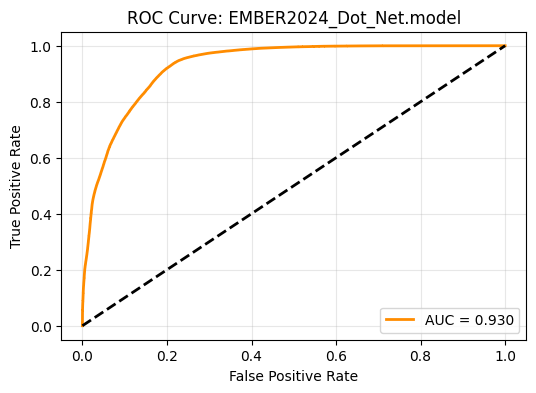

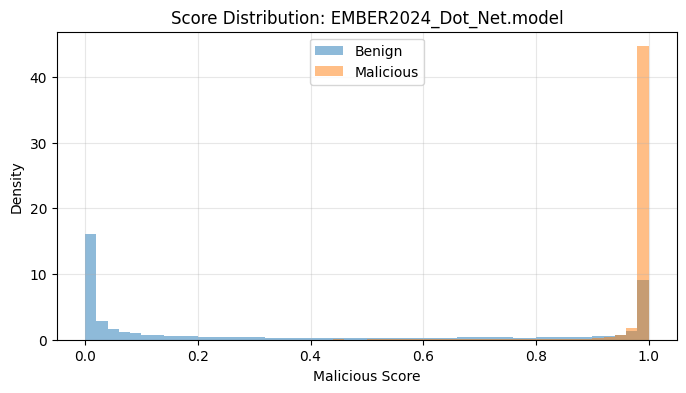

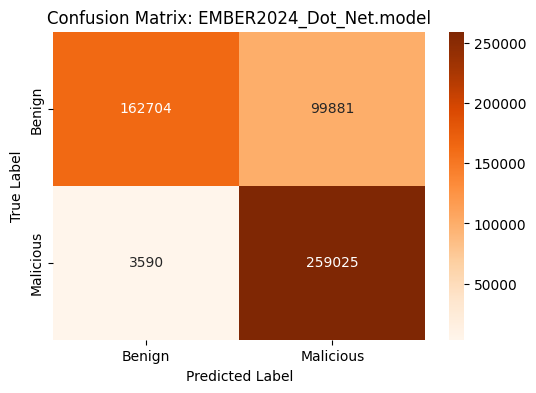

<Figure size 1000x800 with 0 Axes>

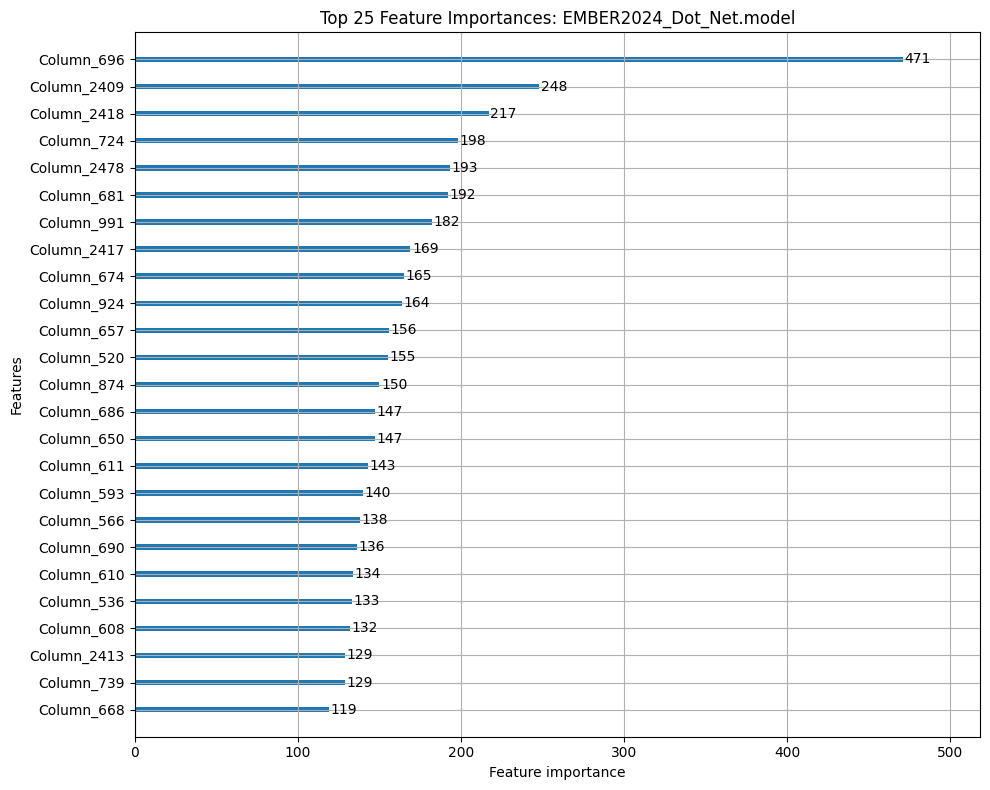

Finished evaluating EMBER2024_Dot_Net.model



In [6]:
DATASET_DIR = r"Z:\ember2024_train_data"
MODELS_DIR = r"C:\Users\him\ember2024_project\benchmark_models"
SPECIFIC_MODEL_PATH = r"C:\Users\him\ember2024_project\benchmark_models\EMBER2024_Dot_Net.model"

# --- TOGGLE THIS SWITCH ---
# Set to True to evaluate all models in the folder.
# Set to False to evaluate ONLY the Specific Model.
TEST_ALL_MODELS = False
# --------------------------

if TEST_ALL_MODELS:
    if not os.path.exists(MODELS_DIR):
        print(f"Directory not found: {MODELS_DIR}")
    else:
        models = [f for f in os.listdir(MODELS_DIR) if f.endswith(".model")]
        if not models:
            print("No .model files found in benchmark directory.")
        else:
            print(f"Found {len(models)} benchmark models: {models}\n")
            
            for i, m in enumerate(models):
                m_path = os.path.join(MODELS_DIR, m)
                print(f"[{i+1}/{len(models)}] Starting {m}...")
                evaluate_benchmark_model(m_path, DATASET_DIR, batch_size=50000)

else:
    if os.path.exists(SPECIFIC_MODEL_PATH):
        print(f"Starting evaluation for {os.path.basename(SPECIFIC_MODEL_PATH)}...")
        evaluate_benchmark_model(SPECIFIC_MODEL_PATH, DATASET_DIR, batch_size=50000)
    else:
        print(f"Error: File not found at {SPECIFIC_MODEL_PATH}")